In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import norm
import random
import math
import sklearn.mixture as mix

In [2]:
data = np.load('formationchannels.npy')

(array([0.00063165, 0.        , 0.00063165, 0.00063165, 0.00063165,
        0.        , 0.00126329, 0.00189494, 0.00126329, 0.00063165,
        0.00252658, 0.00063165, 0.00189494, 0.00442152, 0.00378987,
        0.0069481 , 0.00252658, 0.0069481 , 0.00568481, 0.00947468,
        0.00821139, 0.00568481, 0.0069481 , 0.01200126, 0.01200126,
        0.0069481 , 0.01010633, 0.01073797, 0.01200126, 0.00757974,
        0.00884304, 0.00884304, 0.00568481, 0.00947468, 0.00821139,
        0.00252658, 0.00757974, 0.00631645, 0.00189494, 0.00315823,
        0.00505316, 0.00884304, 0.01452784, 0.02526582, 0.04547847,
        0.07390251, 0.09158858, 0.08148226, 0.06569112, 0.03221392,
        0.02400253, 0.01642278, 0.03031898, 0.0277924 , 0.02968733,
        0.02968733, 0.03221392, 0.04611011, 0.03726708, 0.05053163,
        0.04358353, 0.04737341, 0.04926834, 0.05368986, 0.05179492,
        0.0555848 , 0.0543215 , 0.05305821, 0.05053163, 0.04484682,
        0.05495315, 0.03663543, 0.03600379, 0.04

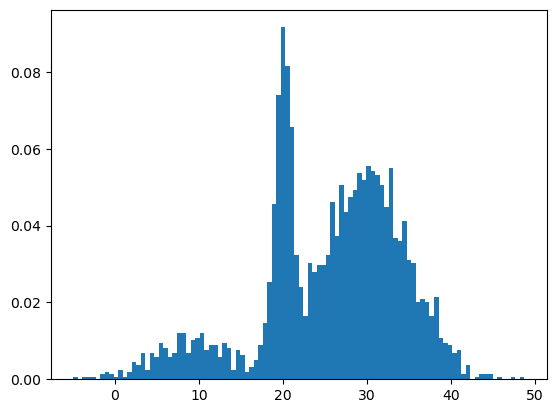

In [3]:
plt.hist(data, bins=np.linspace(np.min(data),np.max(data),101), density=True)

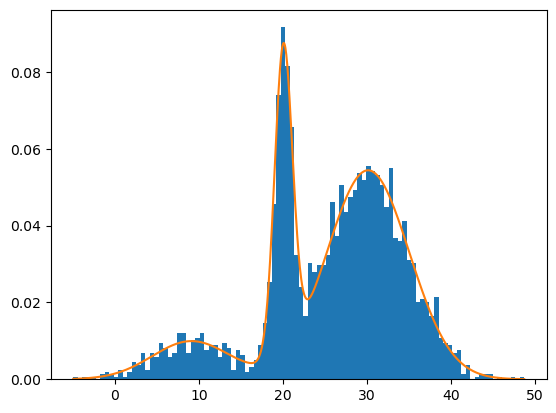

In [5]:
gm = mix.GaussianMixture(3).fit(data) #fit per gaussianMixture di 3 gaussiane
y = gm.score_samples(np.linspace(np.min(data),np.max(data),1000)[:,np.newaxis]) #definizione delle y come log-likelihood dei dati (ultima parentesi per corretto formato dati)

plt.hist(data, bins=np.linspace(np.min(data),np.max(data),101), density=True)
plt.plot(np.linspace(np.min(data),np.max(data),1000), np.exp(y))

Text(0.5, 0, 'number of gaussians')

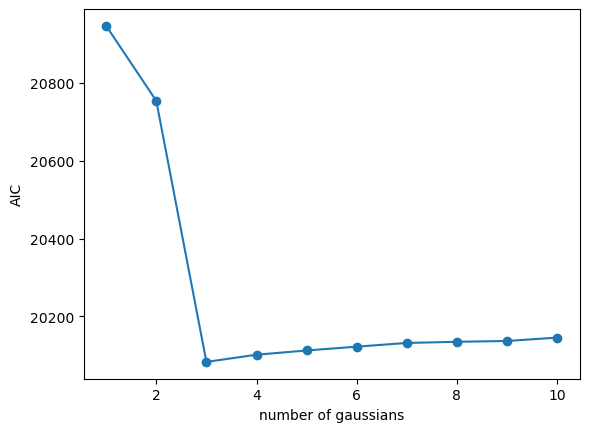

In [9]:
#prova del gaussianmixture sui dati considerano N = 1, 2, .., 10 gaussiane: la migliore scelta è quella che minimizza l'AIC
gm_N = []
N = np.linspace(1,10,10, dtype=int)
[gm_N.append(mix.GaussianMixture(n).fit(data).aic(data)) for n in N]
plt.plot(N,gm_N, '-o')
plt.ylabel('AIC')
plt.xlabel('number of gaussians')

We choose the minimum one because the others will add parameters to the model (and we want them to be the less possible to have less complexity)

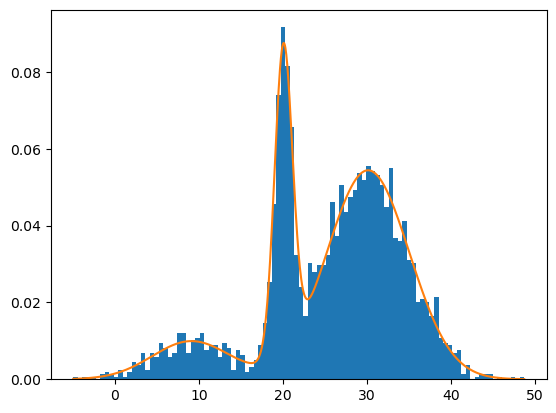

In [11]:
#fit dei dati con la migliore scelta trovata (minimo AIC)
gm_min = mix.GaussianMixture(N[np.argmin(gm_N)]).fit(data)
y_min = gm_min.score_samples(np.linspace(np.min(data),np.max(data),1000)[:,np.newaxis])

plt.hist(data, bins=np.linspace(np.min(data),np.max(data),101), density=True)
plt.plot(np.linspace(np.min(data),np.max(data),1000), np.exp(y))

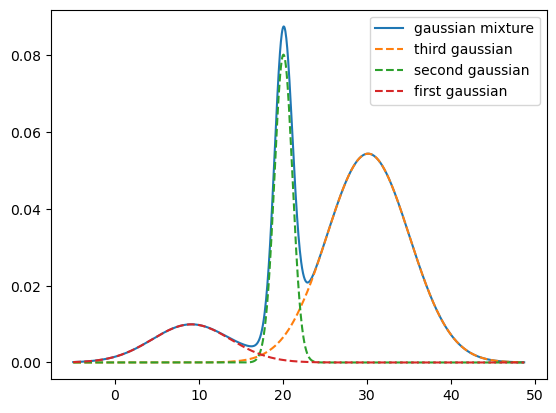

In [14]:
#data gaussian density: plot delle "singole gaussiane" (moltiplico le y per la probabilità associata)
data_gd = gm_min.predict_proba(np.linspace(np.min(data),np.max(data),1000)[:,np.newaxis])
plt.plot(np.linspace(np.min(data),np.max(data),1000), np.exp(y), label='gaussian mixture')
plt.plot(np.linspace(np.min(data),np.max(data),1000), data_gd[:,0]*np.exp(y), '--', label='third gaussian')
plt.plot(np.linspace(np.min(data),np.max(data),1000), data_gd[:,1]*np.exp(y), '--', label='second gaussian')
plt.plot(np.linspace(np.min(data),np.max(data),1000), data_gd[:,2]*np.exp(y), '--', label='first gaussian')
plt.legend()

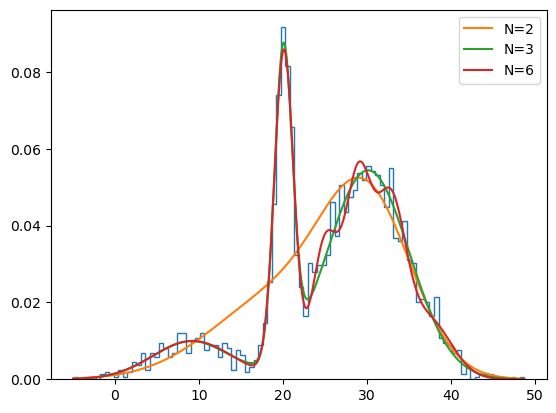

In [19]:
x = np.linspace(np.min(data),np.max(data),1000)
plt.hist(data, bins=np.linspace(np.min(data),np.max(data),101), histtype='step', density=True)
plt.plot(x, np.exp(mix.GaussianMixture(2).fit(data).score_samples(x[:,np.newaxis])), label='N=2')
plt.plot(x, np.exp(mix.GaussianMixture(3).fit(data).score_samples(x[:,np.newaxis])), label='N=3')
plt.plot(x, np.exp(mix.GaussianMixture(6).fit(data).score_samples(x[:,np.newaxis])), label='N=6')
plt.legend()